In [3]:
from factors.factor_auto_search import FactorFusioner
import json
import pandas as pd

In [4]:
fusioner = FactorFusioner(
        fusion_method='avg_weight',
        raw_factor_dict=None,
        collection='genetic_programming',
        instrument_id_list='C0',
        start_time='20200101',
        end_time='20241231',
        max_fusion_count=3,
        fusion_metrics='ic',
        apply_weighted_price=True,
        version='20260412_factor_fusion_test_1',
        n_jobs=1,
    )

result = fusioner.fuse()
out = {
        'fusion_method': result['fusion_method'],
        'fusion_metrics': result['fusion_metrics'],
        'selected_factor_keys': result['selected_factor_keys'],
        'final_metrics': result['final_metrics'],
        'selected_factors_detail': result['selected_factors_detail'],
        }
print(json.dumps(out, ensure_ascii=True, indent=2))

{
  "fusion_method": "avg_weight",
  "fusion_metrics": [
    "ic"
  ],
  "selected_factor_keys": [
    "20260409_gp_test_1::fac_gp_0003",
    "20260408_gp_test_2::fac_gp_0003",
    "20260403_gp_test_4::fac_gp_0003"
  ],
  "final_metrics": {
    "ic": 0.2185023755058589,
    "sharpe": 3.236833906086936
  },
  "selected_factors_detail": [
    {
      "factor_key": "20260409_gp_test_1::fac_gp_0003",
      "version": "20260409_gp_test_1",
      "factor_name": "fac_gp_0003",
      "collection": "genetic_programming",
      "formula": "OpRollNorm(Neg(Add(TsCorr(Min(close, TypicalPrice(Min(open, high))), Mul(Delta(Delta(low)), TsRank(volume, 20)), 5), Abs(VolumeZScore(TsDelta(TsDecayExp(volume, 30), 10), 5)))), 30, 20, 1e-08, 5)"
    },
    {
      "factor_key": "20260408_gp_test_2::fac_gp_0003",
      "version": "20260408_gp_test_2",
      "factor_name": "fac_gp_0003",
      "collection": "genetic_programming",
      "formula": "OpRollNorm(Neg(TurnoverShock(Mul(volume, VpDivergence(TsDelta(S

In [5]:
bt = result.get("bt")

In [6]:
bt.performance_summary

,Gross Return,Net Return,Gross Volatility,Net Volatility,Gross Sharpe,Net Sharpe,Gross Sortino,Net Sortino,Gross MaxDD,Net MaxDD,...,Net MaxDD (With Baseline),Gross Calmar (With Baseline),Net Calmar (With Baseline),Gross Win Rate (With Baseline),Net Win Rate (With Baseline),Turnover (With Baseline),Factor Name,Factor Freq,Fee,Instrument ID
year,,,,,,,,,,,,,,,,,,,,,
2020,0.185756,0.158297,0.090044,0.089731,2.062956,1.764126,1.861303,1.637925,0.068375,0.071619,...,"0.0716186(0.0487138,0.291679)","2.06296(2.75956,-2.75956)","1.76413(2.75777,-2.76134)","0.45679(0.563786,0.411523)","0.436214(0.563786,0.411523)","0.544827(0.00411523,0.00411523)",__fused_factor__,1d,0.0002,C0
2021,0.359788,0.329779,0.081016,0.080812,4.440955,4.080824,9.605335,8.855824,0.021497,0.022806,...,"0.0228057(0.148106,0.111244)","4.44095(0.0391665,-0.0391665)","4.08082(0.0391665,-0.0391665)","0.609053(0.497942,0.489712)","0.572016(0.497942,0.489712)","0.595415(0,0)",__fused_factor__,1d,0.0002,C0
2022,0.202257,0.170635,0.090560,0.090298,2.233418,1.889689,2.639755,2.317283,0.053237,0.056692,...,"0.0566924(0.15486,0.122289)","2.23342(0.267796,-0.267796)","1.88969(0.267796,-0.267796)","0.570248(0.516529,0.466942)","0.524793(0.516529,0.466942)","0.627422(0,0)",__fused_factor__,1d,0.0002,C0
2023,0.242339,0.209787,0.077889,0.077585,3.111331,2.703978,4.312756,3.911489,0.040251,0.043461,...,"0.0434606(0.146334,0.115003)","3.11133(-1.08921,1.08921)","2.70398(-1.08921,1.08921)","0.590909(0.483471,0.491736)","0.545455(0.483471,0.491736)","0.64588(0,0)",__fused_factor__,1d,0.0002,C0
2024,0.345888,0.315331,0.071700,0.071273,4.824069,4.424280,11.339553,10.719571,0.015589,0.017057,...,"0.0170567(0.176943,0.0575955)","4.82407(-1.37663,1.37663)","4.42428(-1.37663,1.37663)","0.545455(0.417355,0.541322)","0.512397(0.417355,0.541322)","0.606274(0,0)",__fused_factor__,1d,0.0002,C0
all,0.267215,0.236778,0.082554,0.082257,3.236834,2.878501,4.130207,3.824825,0.068375,0.071619,...,"0.0716186(0.30725,0.362493)","3.23683(0.176769,-0.176769)","2.8785(0.176421,-0.177116)","0.554455(0.495875,0.480198)","0.518152(0.495875,0.480198)","0.603908(0.000825083,0.000825083)",__fused_factor__,1d,0.0002,C0
2020,0.184984,0.141328,0.128129,0.127860,1.443727,1.105334,1.378160,1.092532,0.090995,0.095048,...,"0.0950476(0.0487138,0.291679)","1.44373(2.75956,-2.75956)","1.10533(2.75777,-2.76134)","0.432099(0.563786,0.411523)","0.399177(0.563786,0.411523)","0.866177(0.00411523,0.00411523)",20260409_gp_test_1::fac_gp_0003,1d,0.0002,C0
2021,0.365461,0.312669,0.137985,0.137699,2.648560,2.270668,5.141267,4.383210,0.052059,0.056756,...,"0.0567559(0.148106,0.111244)","2.64856(0.0391665,-0.0391665)","2.27067(0.0391665,-0.0391665)","0.534979(0.497942,0.489712)","0.514403(0.497942,0.489712)","1.04745(0,0)",20260409_gp_test_1::fac_gp_0003,1d,0.0002,C0
2022,0.304481,0.252924,0.113340,0.113133,2.686438,2.235627,3.863271,3.245124,0.046342,0.050980,...,"0.0509796(0.15486,0.122289)","2.68644(0.267796,-0.267796)","2.23563(0.267796,-0.267796)","0.553719(0.516529,0.466942)","0.524793(0.516529,0.466942)","1.02295(0,0)",20260409_gp_test_1::fac_gp_0003,1d,0.0002,C0


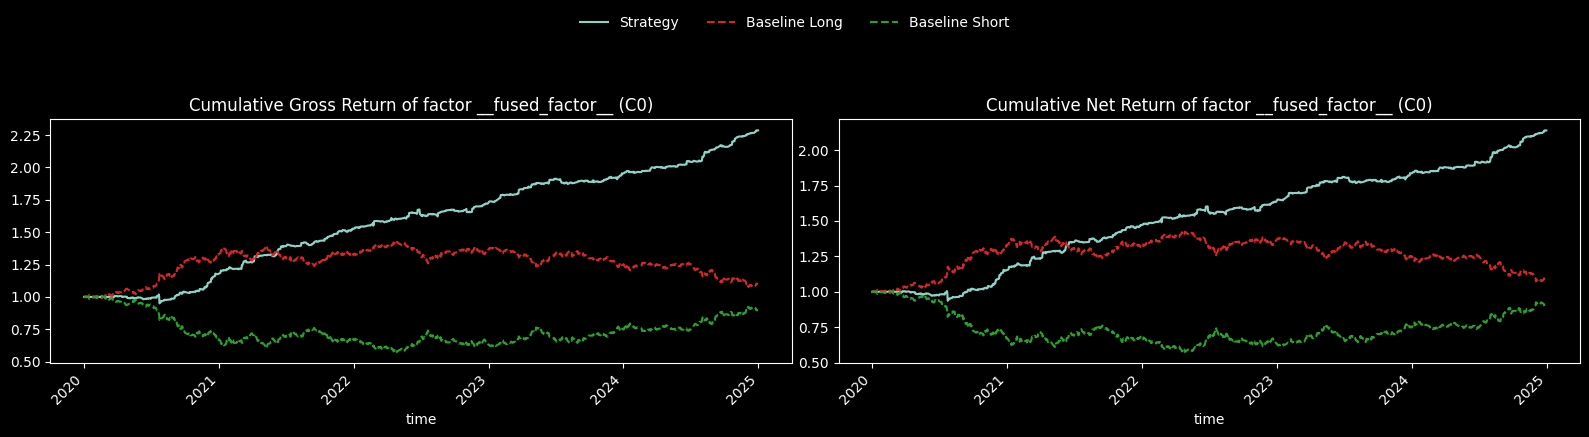

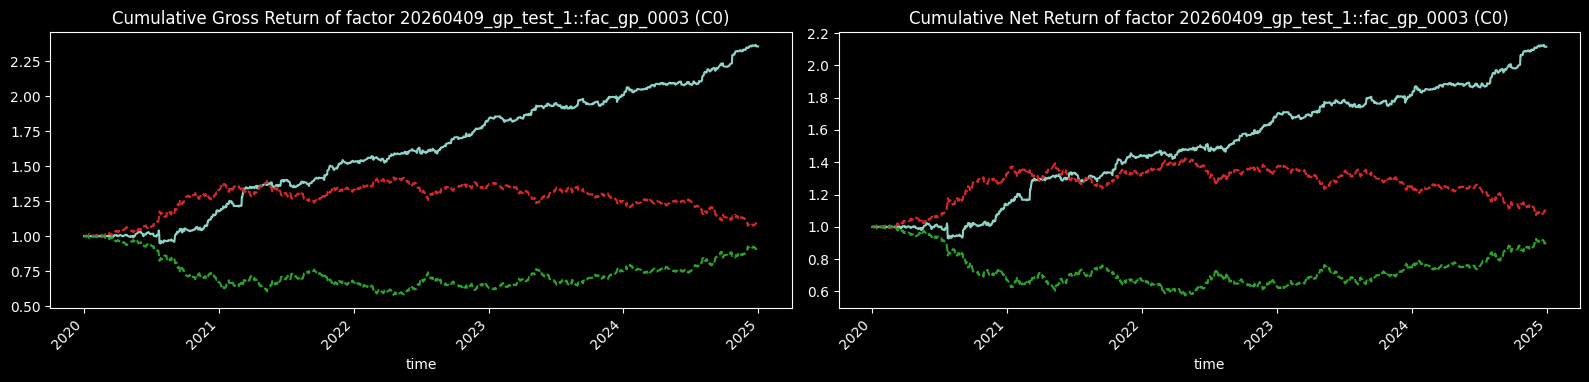

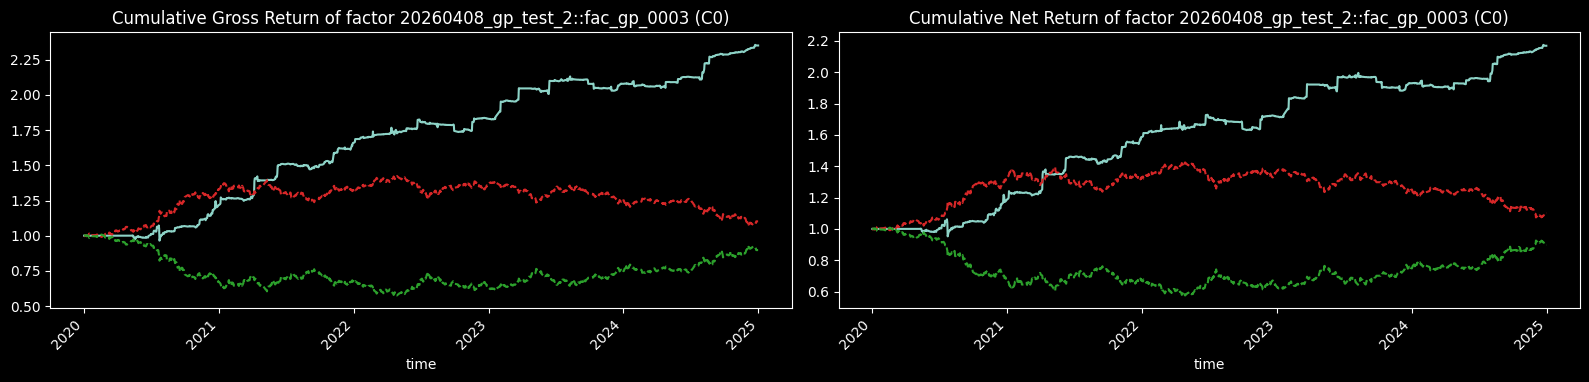

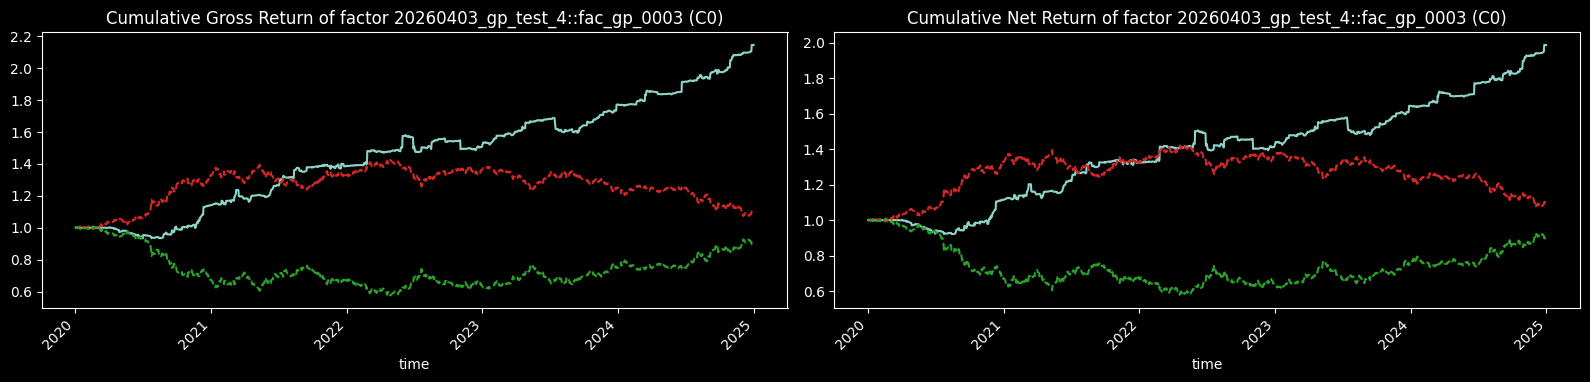

In [8]:
# 净值曲线
start_time = pd.to_datetime('20200101')
end_time = pd.to_datetime('20241231')
fused_name = result["fused_col"]  # "__fused_factor__"
raw_names = result["selected_factor_keys"]

bt.plot_nav(start_time=start_time,
            end_time=end_time,
            fc_name=[fused_name] + raw_names, show_baseline=True)

# 多指标判断融合

In [11]:
fusioner = FactorFusioner(
        fusion_method='avg_weight',
        raw_factor_dict=None,
        collection='genetic_programming',
        instrument_id_list='C0',
        start_time='20200101',
        end_time='20241231',
        max_fusion_count=3,
        fusion_metrics=['ic', 'sharpe'],
        apply_weighted_price=True,
        version='20260412_factor_fusion_test_2',
        n_jobs=1,
    )

result = fusioner.fuse()
out = {
        'fusion_method': result['fusion_method'],
        'fusion_metrics': result['fusion_metrics'],
        'selected_factor_keys': result['selected_factor_keys'],
        'final_metrics': result['final_metrics'],
        'selected_factors_detail': result['selected_factors_detail'],
        }
print(json.dumps(out, ensure_ascii=True, indent=2))

{
  "fusion_method": "avg_weight",
  "fusion_metrics": [
    "ic",
    "sharpe"
  ],
  "selected_factor_keys": [
    "20260409_gp_test_1::fac_gp_0003",
    "20260408_gp_test_2::fac_gp_0003",
    "20260403_gp_test_4::fac_gp_0003"
  ],
  "final_metrics": {
    "ic": 0.2185023755058589,
    "sharpe": 3.236833906086936
  },
  "selected_factors_detail": [
    {
      "factor_key": "20260409_gp_test_1::fac_gp_0003",
      "version": "20260409_gp_test_1",
      "factor_name": "fac_gp_0003",
      "collection": "genetic_programming",
      "formula": "OpRollNorm(Neg(Add(TsCorr(Min(close, TypicalPrice(Min(open, high))), Mul(Delta(Delta(low)), TsRank(volume, 20)), 5), Abs(VolumeZScore(TsDelta(TsDecayExp(volume, 30), 10), 5)))), 30, 20, 1e-08, 5)"
    },
    {
      "factor_key": "20260408_gp_test_2::fac_gp_0003",
      "version": "20260408_gp_test_2",
      "factor_name": "fac_gp_0003",
      "collection": "genetic_programming",
      "formula": "OpRollNorm(Neg(TurnoverShock(Mul(volume, VpDiverg

In [12]:
bt = result.get("bt")

In [13]:
bt.performance_summary

,Gross Return,Net Return,Gross Volatility,Net Volatility,Gross Sharpe,Net Sharpe,Gross Sortino,Net Sortino,Gross MaxDD,Net MaxDD,...,Net MaxDD (With Baseline),Gross Calmar (With Baseline),Net Calmar (With Baseline),Gross Win Rate (With Baseline),Net Win Rate (With Baseline),Turnover (With Baseline),Factor Name,Factor Freq,Fee,Instrument ID
year,,,,,,,,,,,,,,,,,,,,,
2020,0.185756,0.158297,0.090044,0.089731,2.062956,1.764126,1.861303,1.637925,0.068375,0.071619,...,"0.0716186(0.0487138,0.291679)","2.06296(2.75956,-2.75956)","1.76413(2.75777,-2.76134)","0.45679(0.563786,0.411523)","0.436214(0.563786,0.411523)","0.544827(0.00411523,0.00411523)",__fused_factor__,1d,0.0002,C0
2021,0.359788,0.329779,0.081016,0.080812,4.440955,4.080824,9.605335,8.855824,0.021497,0.022806,...,"0.0228057(0.148106,0.111244)","4.44095(0.0391665,-0.0391665)","4.08082(0.0391665,-0.0391665)","0.609053(0.497942,0.489712)","0.572016(0.497942,0.489712)","0.595415(0,0)",__fused_factor__,1d,0.0002,C0
2022,0.202257,0.170635,0.090560,0.090298,2.233418,1.889689,2.639755,2.317283,0.053237,0.056692,...,"0.0566924(0.15486,0.122289)","2.23342(0.267796,-0.267796)","1.88969(0.267796,-0.267796)","0.570248(0.516529,0.466942)","0.524793(0.516529,0.466942)","0.627422(0,0)",__fused_factor__,1d,0.0002,C0
2023,0.242339,0.209787,0.077889,0.077585,3.111331,2.703978,4.312756,3.911489,0.040251,0.043461,...,"0.0434606(0.146334,0.115003)","3.11133(-1.08921,1.08921)","2.70398(-1.08921,1.08921)","0.590909(0.483471,0.491736)","0.545455(0.483471,0.491736)","0.64588(0,0)",__fused_factor__,1d,0.0002,C0
2024,0.345888,0.315331,0.071700,0.071273,4.824069,4.424280,11.339553,10.719571,0.015589,0.017057,...,"0.0170567(0.176943,0.0575955)","4.82407(-1.37663,1.37663)","4.42428(-1.37663,1.37663)","0.545455(0.417355,0.541322)","0.512397(0.417355,0.541322)","0.606274(0,0)",__fused_factor__,1d,0.0002,C0
all,0.267215,0.236778,0.082554,0.082257,3.236834,2.878501,4.130207,3.824825,0.068375,0.071619,...,"0.0716186(0.30725,0.362493)","3.23683(0.176769,-0.176769)","2.8785(0.176421,-0.177116)","0.554455(0.495875,0.480198)","0.518152(0.495875,0.480198)","0.603908(0.000825083,0.000825083)",__fused_factor__,1d,0.0002,C0
2020,0.184984,0.141328,0.128129,0.127860,1.443727,1.105334,1.378160,1.092532,0.090995,0.095048,...,"0.0950476(0.0487138,0.291679)","1.44373(2.75956,-2.75956)","1.10533(2.75777,-2.76134)","0.432099(0.563786,0.411523)","0.399177(0.563786,0.411523)","0.866177(0.00411523,0.00411523)",20260409_gp_test_1::fac_gp_0003,1d,0.0002,C0
2021,0.365461,0.312669,0.137985,0.137699,2.648560,2.270668,5.141267,4.383210,0.052059,0.056756,...,"0.0567559(0.148106,0.111244)","2.64856(0.0391665,-0.0391665)","2.27067(0.0391665,-0.0391665)","0.534979(0.497942,0.489712)","0.514403(0.497942,0.489712)","1.04745(0,0)",20260409_gp_test_1::fac_gp_0003,1d,0.0002,C0
2022,0.304481,0.252924,0.113340,0.113133,2.686438,2.235627,3.863271,3.245124,0.046342,0.050980,...,"0.0509796(0.15486,0.122289)","2.68644(0.267796,-0.267796)","2.23563(0.267796,-0.267796)","0.553719(0.516529,0.466942)","0.524793(0.516529,0.466942)","1.02295(0,0)",20260409_gp_test_1::fac_gp_0003,1d,0.0002,C0


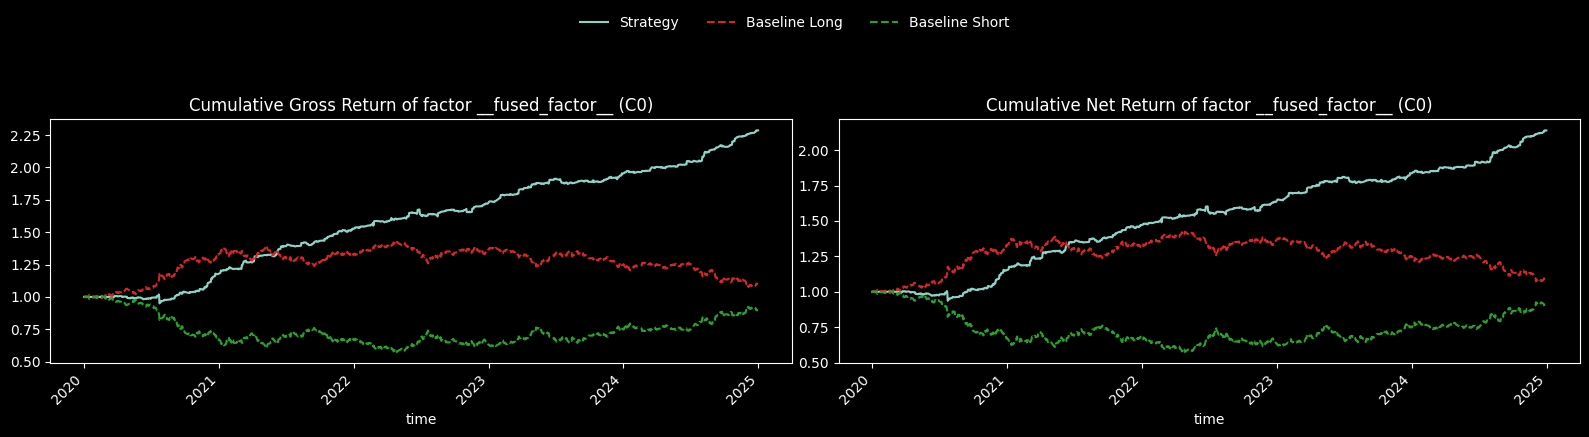

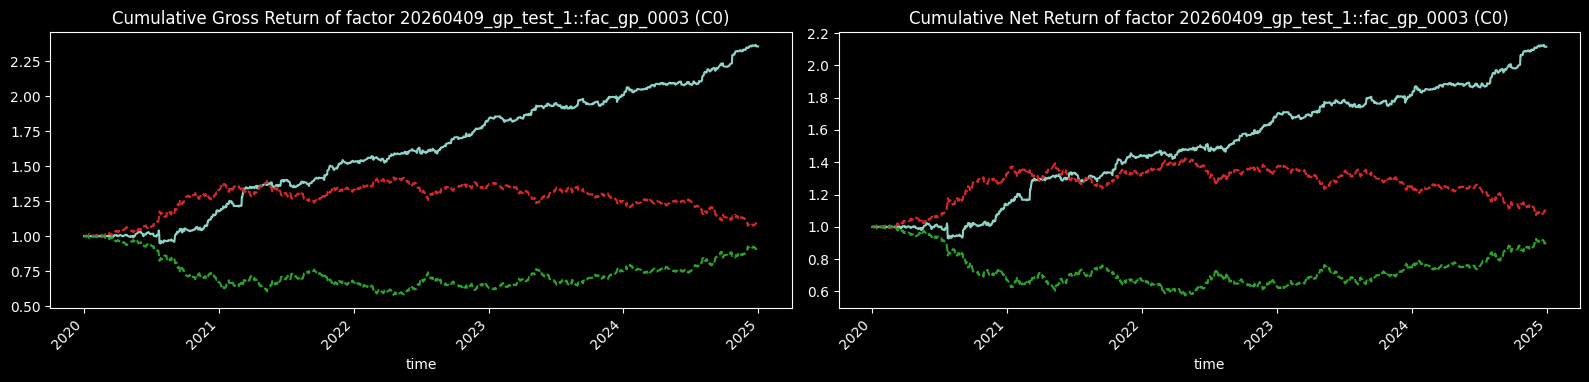

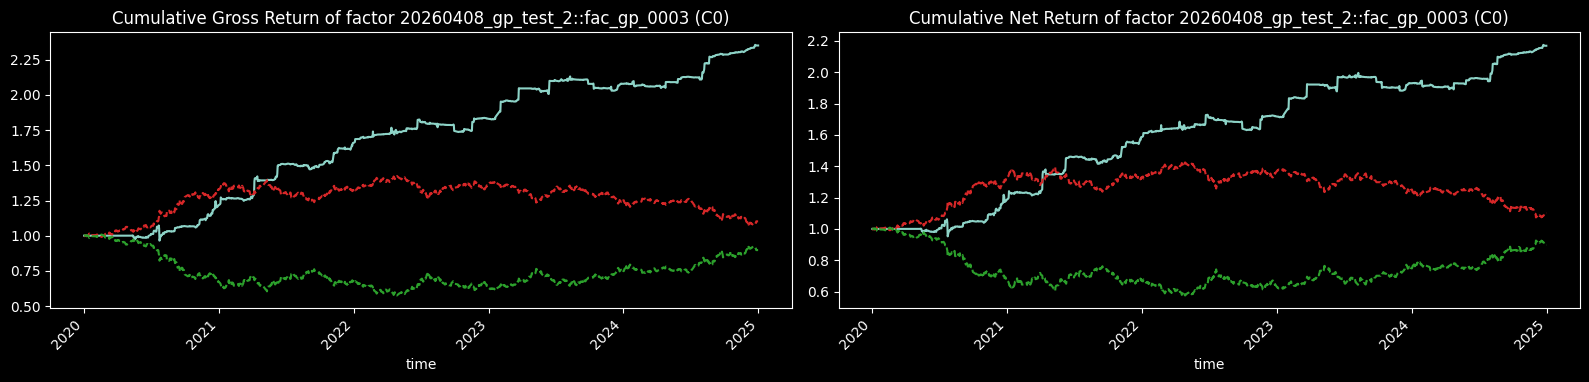

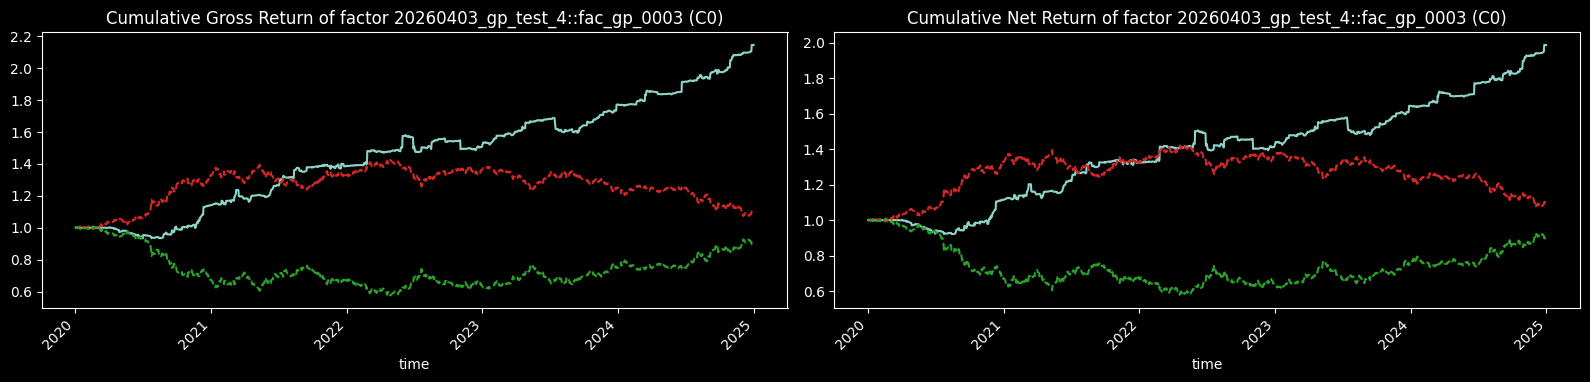

In [14]:
# 净值曲线
start_time = pd.to_datetime('20200101')
end_time = pd.to_datetime('20241231')
fused_name = result["fused_col"]  # "__fused_factor__"
raw_names = result["selected_factor_keys"]

bt.plot_nav(start_time=start_time,
            end_time=end_time,
            fc_name=[fused_name] + raw_names, show_baseline=True)